# Spam Detection: Naive Bayes vs SVM

**Student Name:** Chris and Nathan 
**Date:** 2/26/2026

In this project, you'll:
1. Load a spam email dataset
2. Train a Naive Bayes classifier
3. Train an SVM classifier
4. Compare the results

<small><i>Note</i>: This project was created with the assistance of AI</small>

---

## Step 1: Import Libraries and Load Data

In [49]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
# Set random seed for reproducibility
np.random.seed(42)

In [50]:
# Load the dataset
data = pd.read_csv('../data/spam_data.csv')

# Display first few rows
data

,word_free,word_money,word_winner,word_click,word_urgent,num_exclamation,num_dollar,num_capitals,email_length,has_link,is_spam
0,0.116603,0.081405,0.248621,0.107026,0.084280,0.162809,0.042277,0.240659,101.836546,0.296066,0
1,0.150017,0.202468,0.071720,0.227412,0.228002,0.093779,0.123205,0.062907,90.571442,0.193681,0
2,0.009429,0.190923,0.094307,0.152571,0.272270,0.074788,0.123115,0.226665,130.369345,0.023094,0
3,0.085727,0.129830,0.205633,0.099737,0.016976,0.112176,0.283335,0.192520,98.526674,0.189685,0
4,0.050113,0.050286,0.011001,0.220921,0.199141,0.142389,0.253251,0.241701,96.637459,0.260481,0
...,...,...,...,...,...,...,...,...,...,...,...
995,0.094830,0.016722,0.182944,0.072241,0.116042,0.024174,0.044149,0.089393,121.469609,0.273248,0
996,0.238872,0.081584,0.207708,0.079219,0.281721,0.190912,0.097354,0.080854,66.823658,0.208392,0
997,0.529614,0.466077,1.098918,0.619738,1.067250,0.940798,1.850987,0.669896,92.900492,0.559843,1
998,0.081242,0.074268,0.018758,0.137682,0.219820,0.182020,0.201862,0.024345,117.072733,0.251548,0


## Step 2: Preprocessing the Data
* Clean the data
* Split the data into training and test sets.
* Feature Scaling

In [51]:
print(data.isna().sum())
for col in data:
    if col in ['has_link', 'is_spam']:
        continue
    mini = min(data[col])
    maxi = max(data[col])
    data[col] = (data[col] - mini) / (maxi - mini)

word_free          0
word_money         0
word_winner        0
word_click         0
word_urgent        0
num_exclamation    0
num_dollar         0
num_capitals       0
email_length       0
has_link           0
is_spam            0
dtype: int64


In [52]:
y = data["is_spam"]
X = data.drop(columns=["is_spam"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 3: Train Naive Bayes Classifier

In [ ]:
model = GaussianNB()

model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [54]:
predictions = model.predict(X_test)

RMSE = np.sqrt(np.mean(((predictions - y_test)**2)))

print(RMSE)

0.0


Display your confusion matrix and your classification report.

In [55]:
cd = confusion_matrix(y_test, predictions) 
print(accuracy_score(y_test, predictions))
classification_report(y_test, predictions)

1.0


'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00       113\n           1       1.00      1.00      1.00        87\n\n    accuracy                           1.00       200\n   macro avg       1.00      1.00      1.00       200\nweighted avg       1.00      1.00      1.00       200\n'

## Step 4: Train k-Nearest Neighbors Classifier

In [56]:
knn = KNeighborsClassifier(31)
knn.fit(X_train, y_train)

,n_neighbors,31
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [57]:
knpredictions = knn.predict(X_test)

RMSE = np.sqrt(np.mean(((knpredictions - y_test)**2)))

print(RMSE)

0.0


Display your confusion matrix and classification report.

In [58]:
cd = confusion_matrix(y_test, knpredictions) 
print(accuracy_score(y_test, knpredictions))
print(cd)
print(classification_report(y_test, knpredictions))

1.0
[[113   0]
 [  0  87]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        87

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Step 5: Train SVM Classifier

In [59]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

Display your confusion matrix and your classification report.

In [60]:
print(classification_report(y_test, svm_predictions))
print(confusion_matrix(y_test, svm_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        87

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[113   0]
 [  0  87]]


## Step 6: Compare the Models
* Create graphs that compare model results
* Make calculations to compare model results

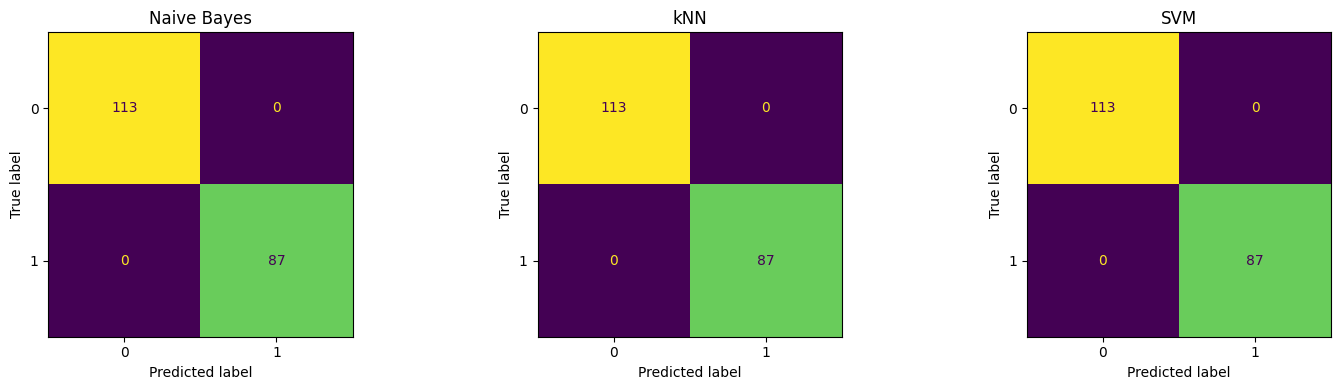

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

model_predictions = {
    "Naive Bayes": model.predict(X_test),
    "kNN": knn.predict(X_test),
    "SVM": svm_model.predict(X_test),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

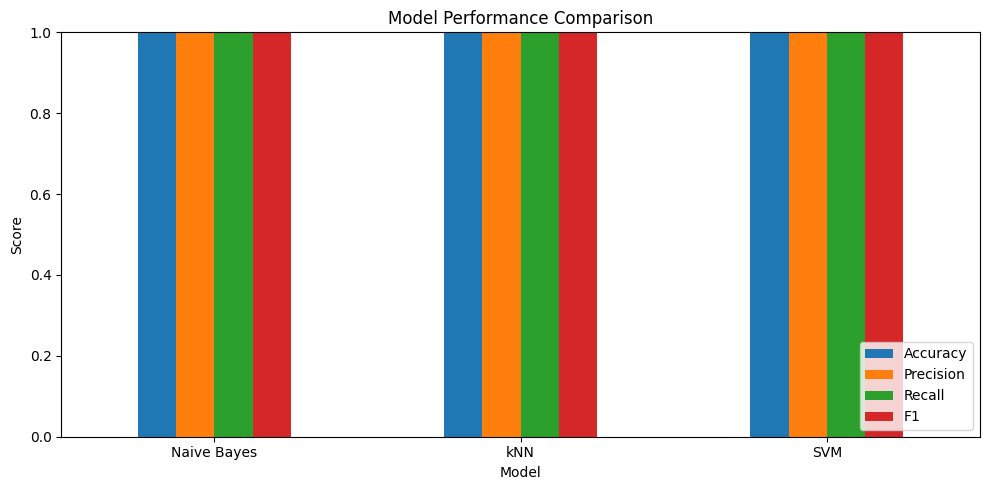

,Accuracy,Precision,Recall,F1
Model,,,,
Naive Bayes,1.0,1.0,1.0,1.0
kNN,1.0,1.0,1.0,1.0
SVM,1.0,1.0,1.0,1.0


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = []
for name, preds in model_predictions.items():
    metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
    })

metrics_df = pd.DataFrame(metrics).set_index("Model")
metrics_df.plot(kind="bar", figsize=(10, 5))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

metrics_df

Discuss the results of your comparison.

## Step 7: Answer Discussion Questions

Based on your results, answer the following questions:

### Question 1: Which model performed better overall? Why do you think so?

**Your Answer:**

They all performed perfectly so according to the data that we recieved there is no way to tell which model did better or worse
---

### Question 2: What is the difference between accuracy and precision? Which is more important for spam detection?

**Your Answer:**

Accuracy is all classifications that are correct. Precision is all positive predictions vs true positives. Accuracy is probably more important as we don't want to do false positives, or you don't want to say that something not spam is spam in case it is important.

---

### Question 3: When would you choose Naive Bayes over kNN or SVM in a real-world application?

**Your Answer:**


I would probably choose Naive Bayes over the other models depending on fitting speed. If the data set were exceptionally large, and largely independent, both in number and degree I would prefer it as it would train significantly faster while remaining accurate

---

### Question 4: What are the key assumptions of Naive Bayes? Do you think they hold true for this spam detection problem?

**Your Answer:**

The key assumption is that all variables are independent. Yes I would say this holds true for this data set; the presence of words definitely might influence the presence of other words, however, if the two of the words are together present that increases the likelihood that it is in fact spam, thus inferring that they are reasonably independent.

---

### Question 5: How did you determine your value for $k$ in the kNN model?

**Your Answer:**

Given the size of the data set n (1000) we found a prime number near the value sqrt(n) which was slightly over 31. We used 31.0 which is prime.

---

## Summary

In this project, you:
- ✅ Loaded and split a spam detection dataset
- ✅ Trained a Naive Bayes classifier
- ✅ Trained an SVM classifier  
- ✅ Compared both models using multiple metrics
- ✅ Analyzed the results

**Key Takeaways:**
1. Different algorithms can produce different results on the same data
2. Multiple metrics (accuracy, precision, recall) give a complete picture
3. Both Naive Bayes and SVM are effective for classification tasks
4. The choice of algorithm depends on the specific requirements of your problem